## Sentiment shifts -  FULL DATASET ANALYSIS ONLY

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#df = pd.read_csv("../Sample/Datasets/Sample_master.tsv", sep="\t", encoding="utf-8") #--> Sample dataset input

df = pd.read_csv("../ParlaMint-SI_full_dataset.tsv", sep="\t", encoding="utf-8") #--> Full dataset input
print("Full dataset shape:", df.shape)
df = df[df["Speaker_role"] != "Chairperson"]#Remove chairperson speakers to not include procedural speeches
print("Dataset shape:", df.shape)

df.head()
df.info()

Full dataset shape: (311354, 30)
Dataset shape: (153770, 30)
<class 'pandas.core.frame.DataFrame'>
Index: 153770 entries, 1 to 311352
Data columns (total 30 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ID                  153770 non-null  object 
 1   Text                153770 non-null  object 
 2   Date                153770 non-null  object 
 3   Term                153770 non-null  object 
 4   Meeting             153770 non-null  object 
 5   Subcorpus           153770 non-null  object 
 6   Speaker_role        153770 non-null  object 
 7   Speaker_MP          153770 non-null  object 
 8   Speaker_minister    153770 non-null  object 
 9   Speaker_party       153770 non-null  object 
 10  Speaker_party_name  153770 non-null  object 
 11  Party_status        153770 non-null  object 
 12  Party_orientation   153770 non-null  object 
 13  Speaker_ID          153770 non-null  object 
 14  Speaker_name        153770 n

In [3]:
df["Date"] = pd.to_datetime(df["Date"])

## Party status sentiment shifts

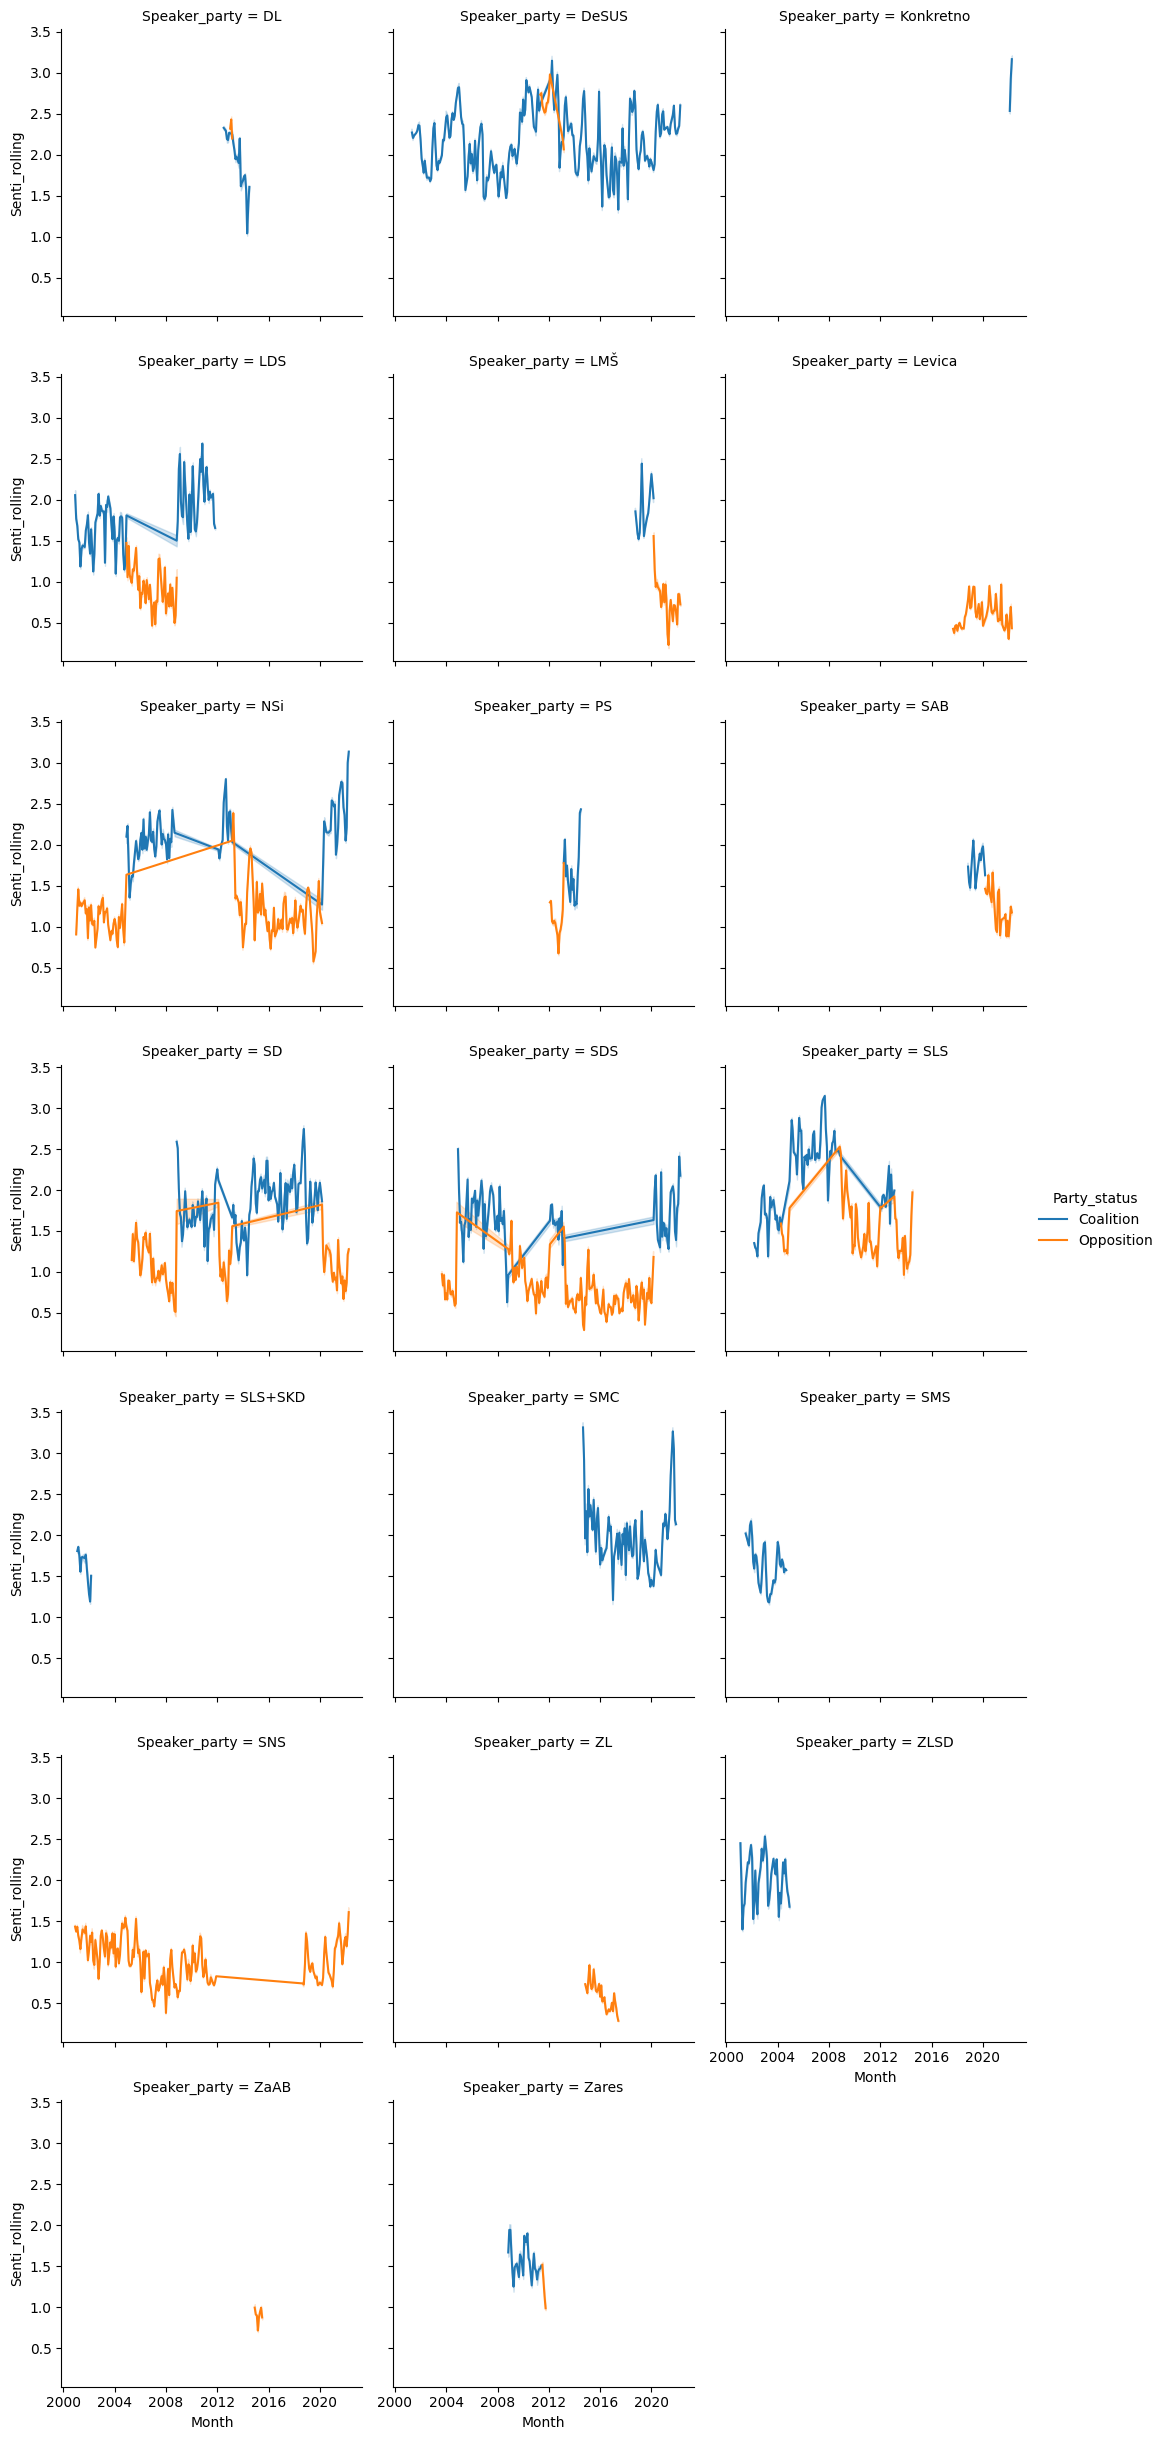

In [4]:
cols = ["IMNS", "-", "NeP", "NP", "Lipa", "DLGV"]
status = df[~df.isin(cols)]
status["Date"] = pd.to_datetime(status["Date"])
status["Year"] = pd.to_datetime(status["Year"])
status["Month"] = status["Date"].dt.to_period("M").dt.to_timestamp()
status = status.sort_values(['Speaker_party', 'Date'])

# Compute rolling mean sentiment over last 30 speeches per party
status['Senti_rolling'] = status.groupby('Speaker_party')['Senti_n'].transform(
    lambda x: x.rolling(65).mean()
)

sns.relplot(
    data=status, x="Month", y='Senti_rolling', hue='Party_status',
    kind='line', col='Speaker_party', col_wrap=3, height=3.5
)
plt.show()

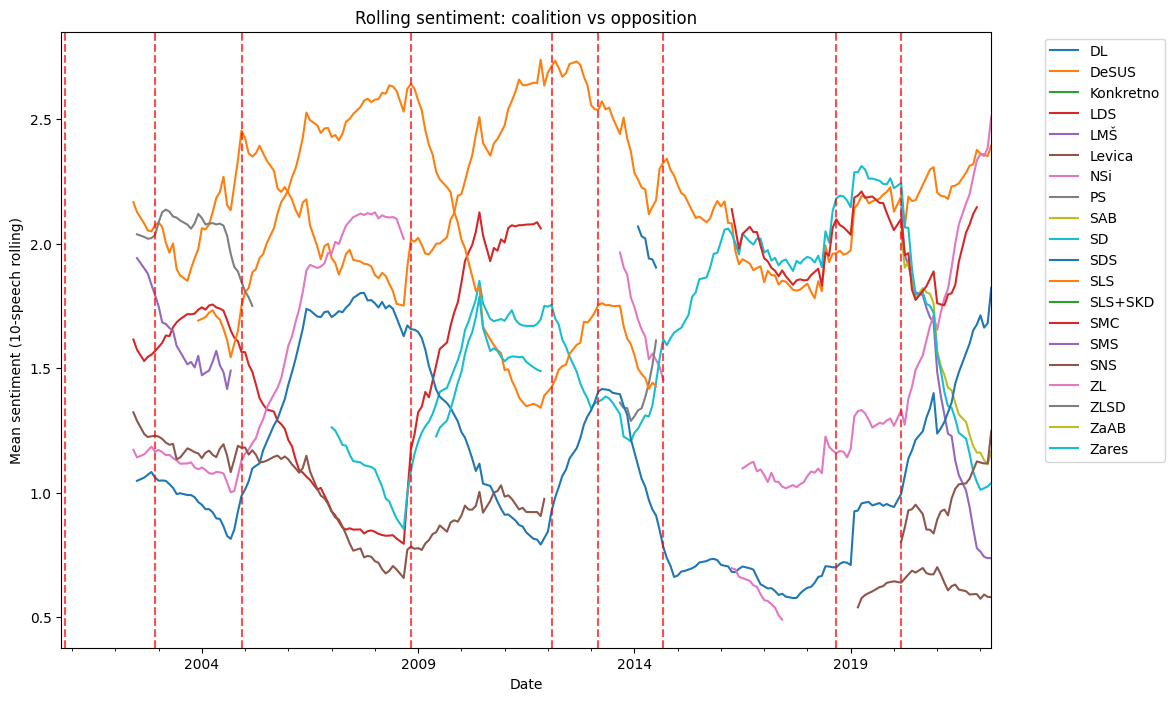

In [5]:
#Dummy gov dates to test for the whole dataset plotting
status["Year"] = status["Year"].astype(int)

gov_changes = [
    ("2000-11-30", "6. Gov (Drnovšek)"),
    ("2002-12-19", "7. Gov (Rop)"),
    ("2004-12-03", "8. Gov (Janša)"),
    ("2008-11-21", "9. Gov (Pahor)"), 
    ("2012-02-10", '10. Gov (Janša)'),
    ("2013-03-20", '11. Gov (Bratušek)'), 
    ("2014-09-18", '12. Gov (Cerar)'),
    ("2018-09-13", '13. Gov (Šarec)'),
    ('2020-03-13', '14. Gov (Janša)'),
    
]
trend_blocs = (
    status.groupby([status["Date"].dt.to_period("M"),'Speaker_party'])['Senti_n']
      .mean().unstack().rolling(20).mean()
)
trend_blocs.plot(figsize=(12,8))
for date, label in gov_changes:
    plt.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.7)
plt.title("Rolling sentiment: coalition vs opposition")
plt.ylabel("Mean sentiment (10-speech rolling)")
plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
plt.show()

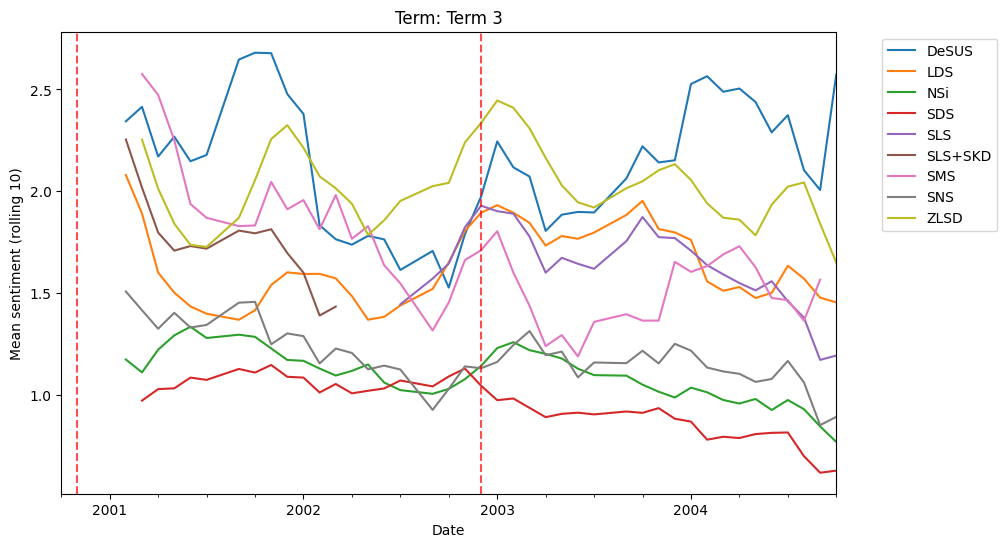

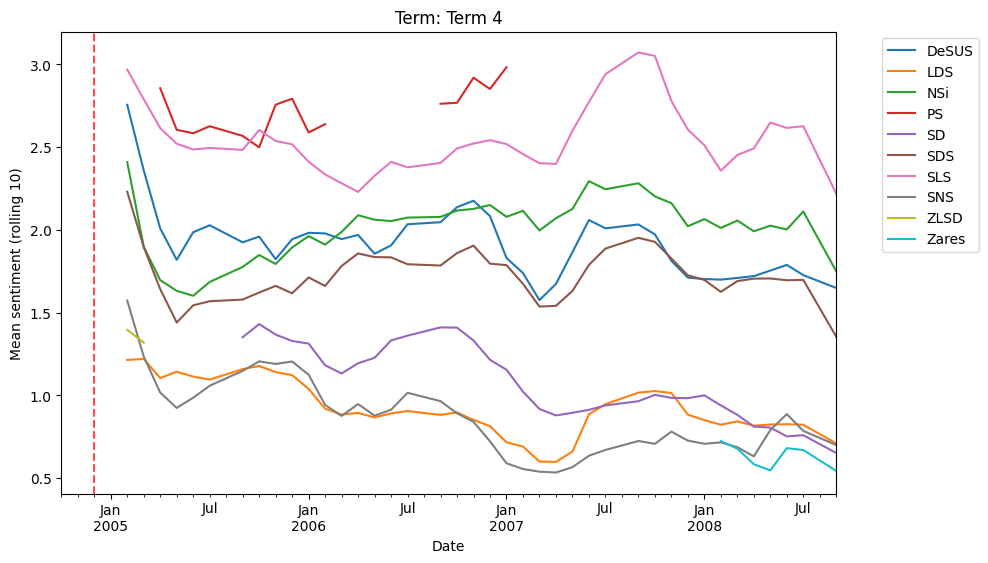

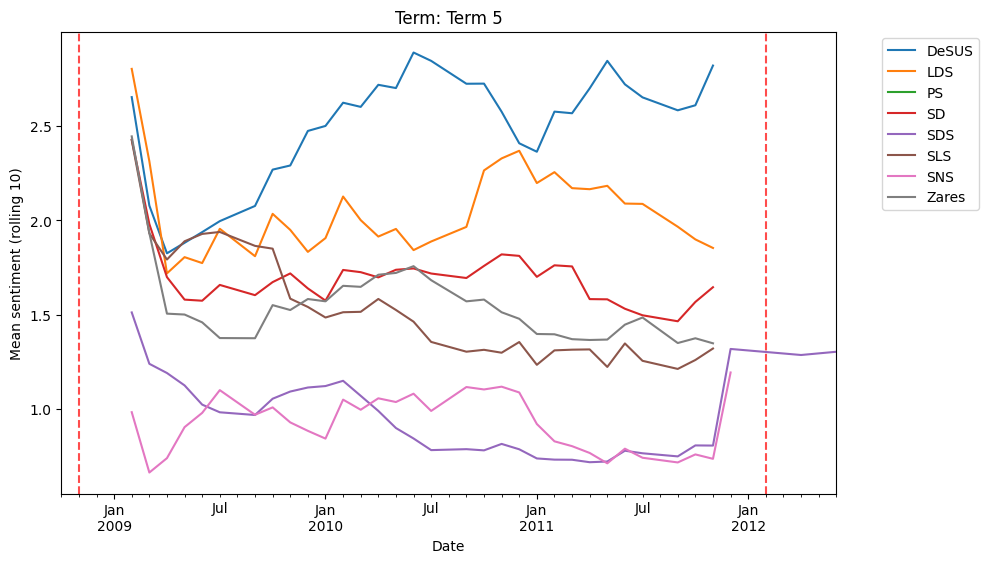

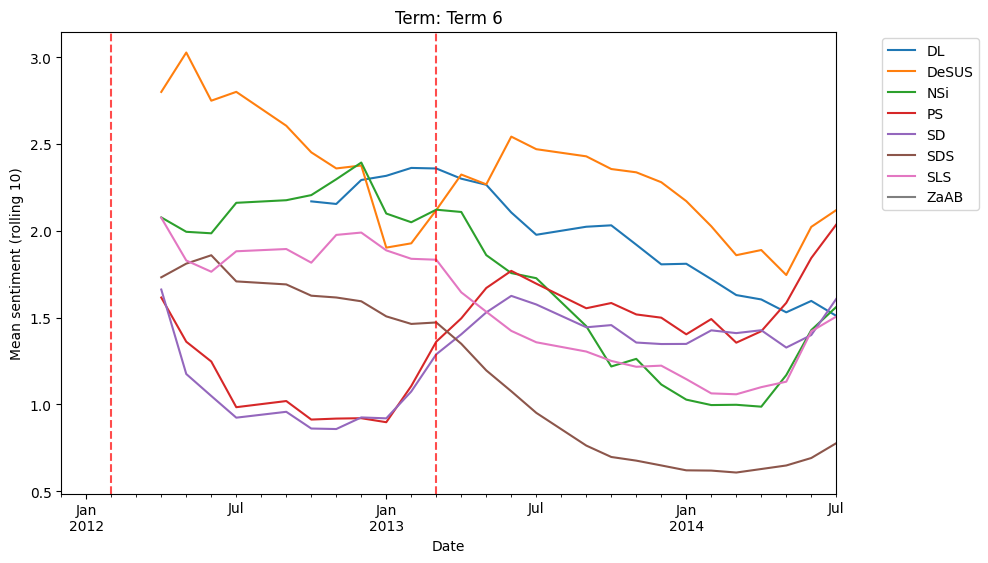

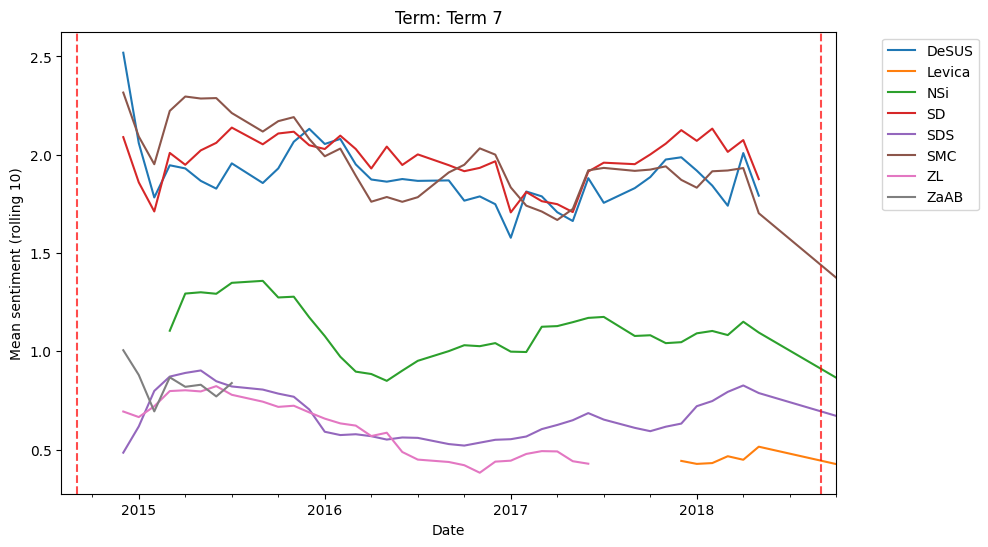

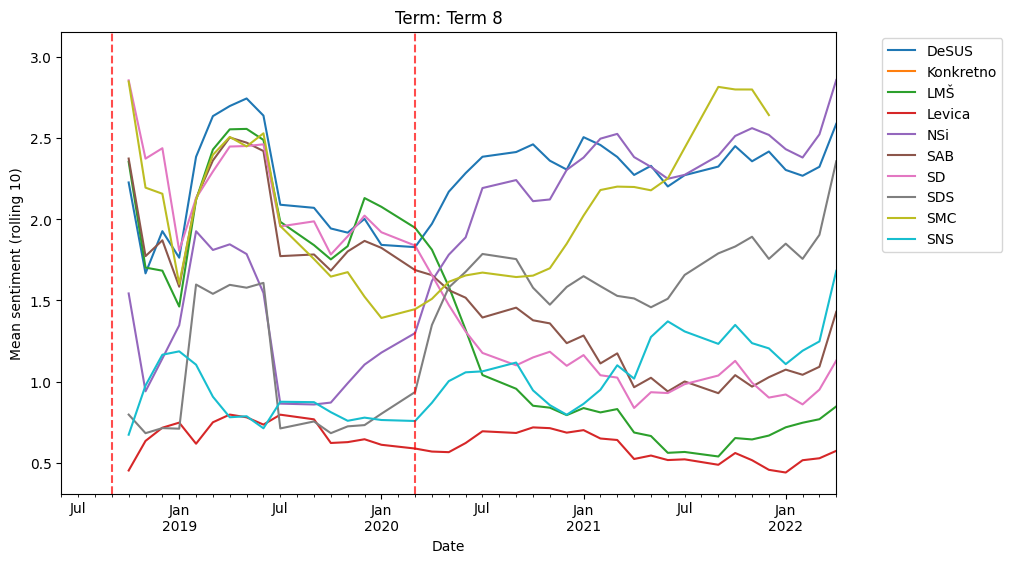

In [6]:
#Individual Term plots (with all government changes in each Term)
for term, sub in status.groupby('Term'):
    trend = sub.groupby([status["Date"].dt.to_period("M"),'Speaker_party'])['Senti_n'].mean().unstack().rolling(5).mean()
    trend.plot(figsize=(10,6), title=f"Term: {term}")
    plt.ylabel("Mean sentiment (rolling 10)")
    for date, label in gov_changes:
        if sub['Date'].min() <= pd.Timestamp(date) <= sub['Date'].max():
            plt.axvline(pd.Timestamp(date), color='red', linestyle='--', alpha=0.7)
        plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.show()

In [7]:
gov_changes = [(pd.Timestamp(d), name) for d, name in gov_changes]
gov_changes

[(Timestamp('2000-11-30 00:00:00'), '6. Gov (Drnovšek)'),
 (Timestamp('2002-12-19 00:00:00'), '7. Gov (Rop)'),
 (Timestamp('2004-12-03 00:00:00'), '8. Gov (Janša)'),
 (Timestamp('2008-11-21 00:00:00'), '9. Gov (Pahor)'),
 (Timestamp('2012-02-10 00:00:00'), '10. Gov (Janša)'),
 (Timestamp('2013-03-20 00:00:00'), '11. Gov (Bratušek)'),
 (Timestamp('2014-09-18 00:00:00'), '12. Gov (Cerar)'),
 (Timestamp('2018-09-13 00:00:00'), '13. Gov (Šarec)'),
 (Timestamp('2020-03-13 00:00:00'), '14. Gov (Janša)')]

In [8]:
from pandas.api.types import CategoricalDtype

sentiment_shifts = []

for i, (change_date, gov_name) in enumerate(gov_changes):
    prev_date = gov_changes[i-1][0] if i > 0 else status['Date'].min()
    next_date = gov_changes[i+1][0] if i+1 < len(gov_changes) else df['Date'].max()
    
    # Define period window (one year before/after for example)
    before = status[(status['Date'] >= prev_date) & (status['Date'] < change_date)]
    after  = status[(status['Date'] >= change_date) & (status['Date'] < next_date)]
    
    # Compute mean sentiment by party or bloc
    before_mean = before.groupby('Speaker_party')['Senti_n'].mean().rename('Before')
    after_mean  = after.groupby('Speaker_party')['Senti_n'].mean().rename('After')
    
    merged = pd.concat([before_mean, after_mean], axis=1)
    merged['Change'] = merged['After'] - merged['Before']
    merged['Gov_change'] = gov_name
    sentiment_shifts.append(merged.reset_index())

sentiment_shift_df = pd.concat(sentiment_shifts, ignore_index=True)
sentiment_shift_df

gov_order = CategoricalDtype(['6. Gov (Drnovšek)', '7. Gov (Rop)', '8. Gov (Janša)', '9. Gov (Pahor)', '10. Gov (Janša)', '11. Gov (Bratušek)', '12. Gov (Cerar)', '13. Gov (Šarec)', '14. Gov (Janša)'], ordered=True)
sentiment_shift_df['Gov_change'] = sentiment_shift_df['Gov_change'].astype(gov_order)

sentiment_shift_df


,Speaker_party,Before,After,Change,Gov_change
0,DeSUS,3.203333,2.056689,-1.146645,6. Gov (Drnovšek)
1,LDS,2.901000,1.528769,-1.372231,6. Gov (Drnovšek)
2,NSi,1.613333,1.184643,-0.428690,6. Gov (Drnovšek)
3,SDS,2.740000,1.061498,-1.678502,6. Gov (Drnovšek)
4,SLS+SKD,2.702222,1.592925,-1.109297,6. Gov (Drnovšek)
...,...,...,...,...,...
89,SD,1.844199,1.018804,-0.825395,14. Gov (Janša)
90,SDS,0.747137,1.689168,0.942030,14. Gov (Janša)
91,SMC,1.638247,2.080694,0.442447,14. Gov (Janša)
92,SNS,0.907553,1.167805,0.260252,14. Gov (Janša)


In [9]:
sentiment_shift_df.pivot_table(
    index='Speaker_party', columns='Gov_change', values='Change', observed=True
).round(2)

Gov_change,6. Gov (Drnovšek),7. Gov (Rop),8. Gov (Janša),9. Gov (Pahor),10. Gov (Janša),11. Gov (Bratušek),12. Gov (Cerar),13. Gov (Šarec),14. Gov (Janša)
Speaker_party,,,,,,,,,
DL,NaN,NaN,NaN,NaN,NaN,-0.48,NaN,NaN,NaN
DeSUS,-1.15,0.24,-0.43,0.60,-0.17,-0.07,-0.31,0.04,0.46
LDS,-1.37,0.09,-0.69,1.07,NaN,NaN,NaN,NaN,NaN
LMŠ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.35,-1.04
Levica,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.24,-0.11
NSi,-0.43,-0.15,0.97,0.02,0.23,-0.94,-0.23,0.04,1.31
PS,NaN,NaN,NaN,-0.93,-0.77,0.57,NaN,NaN,NaN
SAB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.37,-0.53
SD,NaN,NaN,NaN,0.60,-0.68,0.43,0.59,-0.18,-0.83


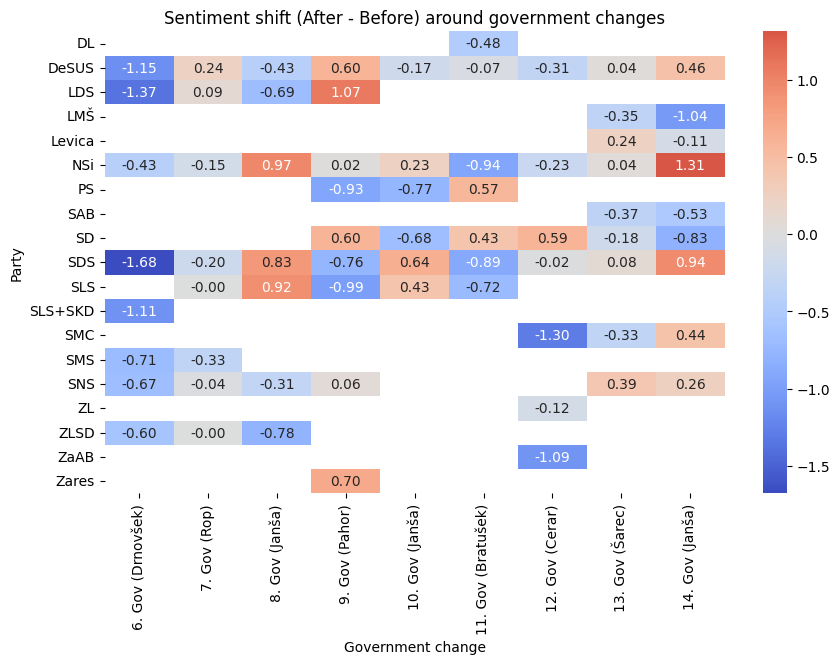

In [10]:
import seaborn as sns
plt.figure(figsize=(10,6))


sns.heatmap(
    sentiment_shift_df.pivot_table(
        index='Speaker_party', columns='Gov_change', observed=True, values='Change',
    ),
    cmap='coolwarm', center=0, annot=True, fmt=".2f"
)
plt.title('Sentiment shift (After - Before) around government changes')
plt.ylabel('Party')
plt.xlabel('Government change')
plt.show()

In [11]:
## Political orientation sentiment shifts
#sns.relplot(
#    data=df, x='Date', y='Senti_rolling', hue='Party_orientation',
#    kind='line', col='Speaker_party', col_wrap=3, height=4
#)
#plt.show()

## Political orientation sentiment shifts

In [12]:
df


,ID,Text,Date,Term,Meeting,Subcorpus,Speaker_role,Speaker_MP,Speaker_minister,Speaker_party,...,Senti_n,Sents,Words,Tokens,Parties,Year,party_id,lrgen,galtan,Seat
1,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u2,Hvala lepa za besedo. Spoštovana predsednica V...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.33,19,284,327,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
3,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u4,"Spoštovane poslanke in poslanci, lep pozdrav p...",2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,-,...,3.51,29,562,662,-,2013,NaN,NaN,NaN,NaN
5,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u6,Hvala lepa še enkrat za besedo. Spoštovana pre...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,0.16,14,227,266,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
7,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u8,Najlepša hvala. Spoštovani poslanec! Jaz misli...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,-,...,2.72,18,226,269,-,2013,NaN,NaN,NaN,NaN
9,ParlaMint-SI_2013-03-27-SDZ6-Redna-12.u10,Res je. Hvala še enkrat za besedo. Na podlagi ...,2013-03-27,Term 6,Redna,Reference,Regular,MP,notMinister,SLS,...,1.28,7,111,130,SLS+SKD/SLS,2013,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311344,ParlaMint-SI_2004-12-03-SDZ4-Izredna-04.u246,"Prisegam, da bom spoštoval ustavni red, da bom...",2004-12-03,Term 4,Izredna,Reference,Regular,notMP,Minister,-,...,3.02,1,21,24,-,2004,NaN,NaN,NaN,NaN
311346,ParlaMint-SI_2004-12-03-SDZ4-Izredna-04.u248,"Prisegam, da bom spoštoval ustavni red, da bom...",2004-12-03,Term 4,Izredna,Reference,Regular,notMP,Minister,-,...,3.02,1,21,24,-,2004,NaN,NaN,NaN,NaN
311348,ParlaMint-SI_2004-12-03-SDZ4-Izredna-04.u250,"Prisegam, da bom spoštoval ustavni red, da bom...",2004-12-03,Term 4,Izredna,Reference,Regular,MP,Minister,SDS,...,3.02,1,21,24,SDS,2004,NaN,NaN,NaN,NaN
311350,ParlaMint-SI_2004-12-03-SDZ4-Izredna-04.u252,"Prisegam, da bom spoštoval ustavni red, da bom...",2004-12-03,Term 4,Izredna,Reference,Regular,notMP,Minister,-,...,3.02,1,21,24,-,2004,NaN,NaN,NaN,NaN


In [13]:
check = df[["Year", "Speaker_party", "Parties", "lrgen", "galtan"]].drop_duplicates().sort_values(by="Year").reset_index(drop=True)

#check.to_csv("LRGEN-GALTAN_check.csv") #Sanity check of the initial lrgen/galtan values before interpolation procedure
check

,Year,Speaker_party,Parties,lrgen,galtan
0,2000,SNS,SNS,NaN,NaN
1,2000,NSi,NSi,NaN,NaN
2,2000,-,-,NaN,NaN
3,2000,SDS,SDS,NaN,NaN
4,2000,DeSUS,DeSUS,NaN,NaN
...,...,...,...,...,...
258,2022,SAB,ZaAB/ZaSLD/SAB,NaN,NaN
259,2022,NSi,NSi,NaN,NaN
260,2022,SNS,SNS,NaN,NaN
261,2022,IMNS,IMNS,NaN,NaN


In [14]:
party_interp = (df.groupby(["Speaker_party", "Year"], as_index=False)[["lrgen", "galtan"]].mean().sort_values(["Speaker_party", "Year"]))
party_interp.head()

,Speaker_party,Year,lrgen,galtan
0,-,2000,NaN,NaN
1,-,2001,NaN,NaN
2,-,2002,NaN,NaN
3,-,2003,NaN,NaN
4,-,2004,NaN,NaN


### Interpolating the CHES values for sentiment switch trends
Given the relatively scares points from the CHES dataset, we decided to interpolate the values for individual years. As we do not want to predic the values for years at both ends of the spectrum (e.g. 2000-2002; 2020-2022), we limit the interpolation method with "both" parameter (values on both ends assume the value of the last Year in CHES dataset (2002 and 2019 respectively))

In [15]:
party_interp[["lrgen", "galtan"]] = (party_interp.groupby("Speaker_party")[["lrgen", "galtan"]].apply(lambda x: x.interpolate(limit_direction="both")).reset_index(drop=True))
party_interp["lrgen"] = party_interp["lrgen"].apply(lambda x: f"{x:.2f}")
party_interp["galtan"] = party_interp["galtan"].apply(lambda x: f"{x:.2f}")

#party_interp.to_csv("LRGEN-GALTAN-sanity-check.csv") #Manual check if interpolation makes sense

In [16]:
df = df.drop(columns=["lrgen", "galtan"]).merge(party_interp, on=["Speaker_party", "Year"], how="left")
df.head()
df.to_csv("../Results/Datasets/ParlaMint_CHES_interpolated_values.tsv", sep="\t",  encoding='utf-8', index=False)

### Relation between lrgen and sentiment 

In [17]:
df["lrgen"] = pd.to_numeric(df["lrgen"], errors="coerce")
df["Senti_n"] = pd.to_numeric(df["Senti_n"], errors="coerce")
df["Year"] = df["Year"].astype(int)

sent_lrgen = df.groupby(["Parties", "Party_status", "Year"]).agg(
    sentiment = ("Senti_n", "mean"),
    lrgen = ("lrgen", "mean")
).reset_index()

#cols = ["IMNS", "-", "NeP", "NP", "Lipa", "DLGV", "DL", "Konkretno"] #Speaker_party
cols = ["IMNS", "-", "NeP", "NP", "Lipa", "DLGV/DL", "Konkretno"] #Parties

sent_lrgen = sent_lrgen[~sent_lrgen.isin(cols)]
sent_lrgen.head(10)
sent_lrgen.shape

(299, 5)

In [18]:
sent_lrgen = sent_lrgen.melt(
    id_vars=["Parties", "Party_status", "Year"],
    value_vars=["sentiment", "lrgen"],
    var_name="Metric",
    value_name="Value"
)
sent_lrgen

,Parties,Party_status,Year,Metric,Value
0,NaN,NaN,2000,sentiment,2.710400
1,NaN,NaN,2001,sentiment,2.145257
2,NaN,NaN,2002,sentiment,2.049008
3,NaN,NaN,2003,sentiment,2.177101
4,NaN,NaN,2004,sentiment,2.143899
...,...,...,...,...,...
593,Zares,Coalition,2008,lrgen,3.900000
594,Zares,Coalition,2009,lrgen,3.900000
595,Zares,Coalition,2010,lrgen,3.900000
596,Zares,Coalition,2011,lrgen,3.900000


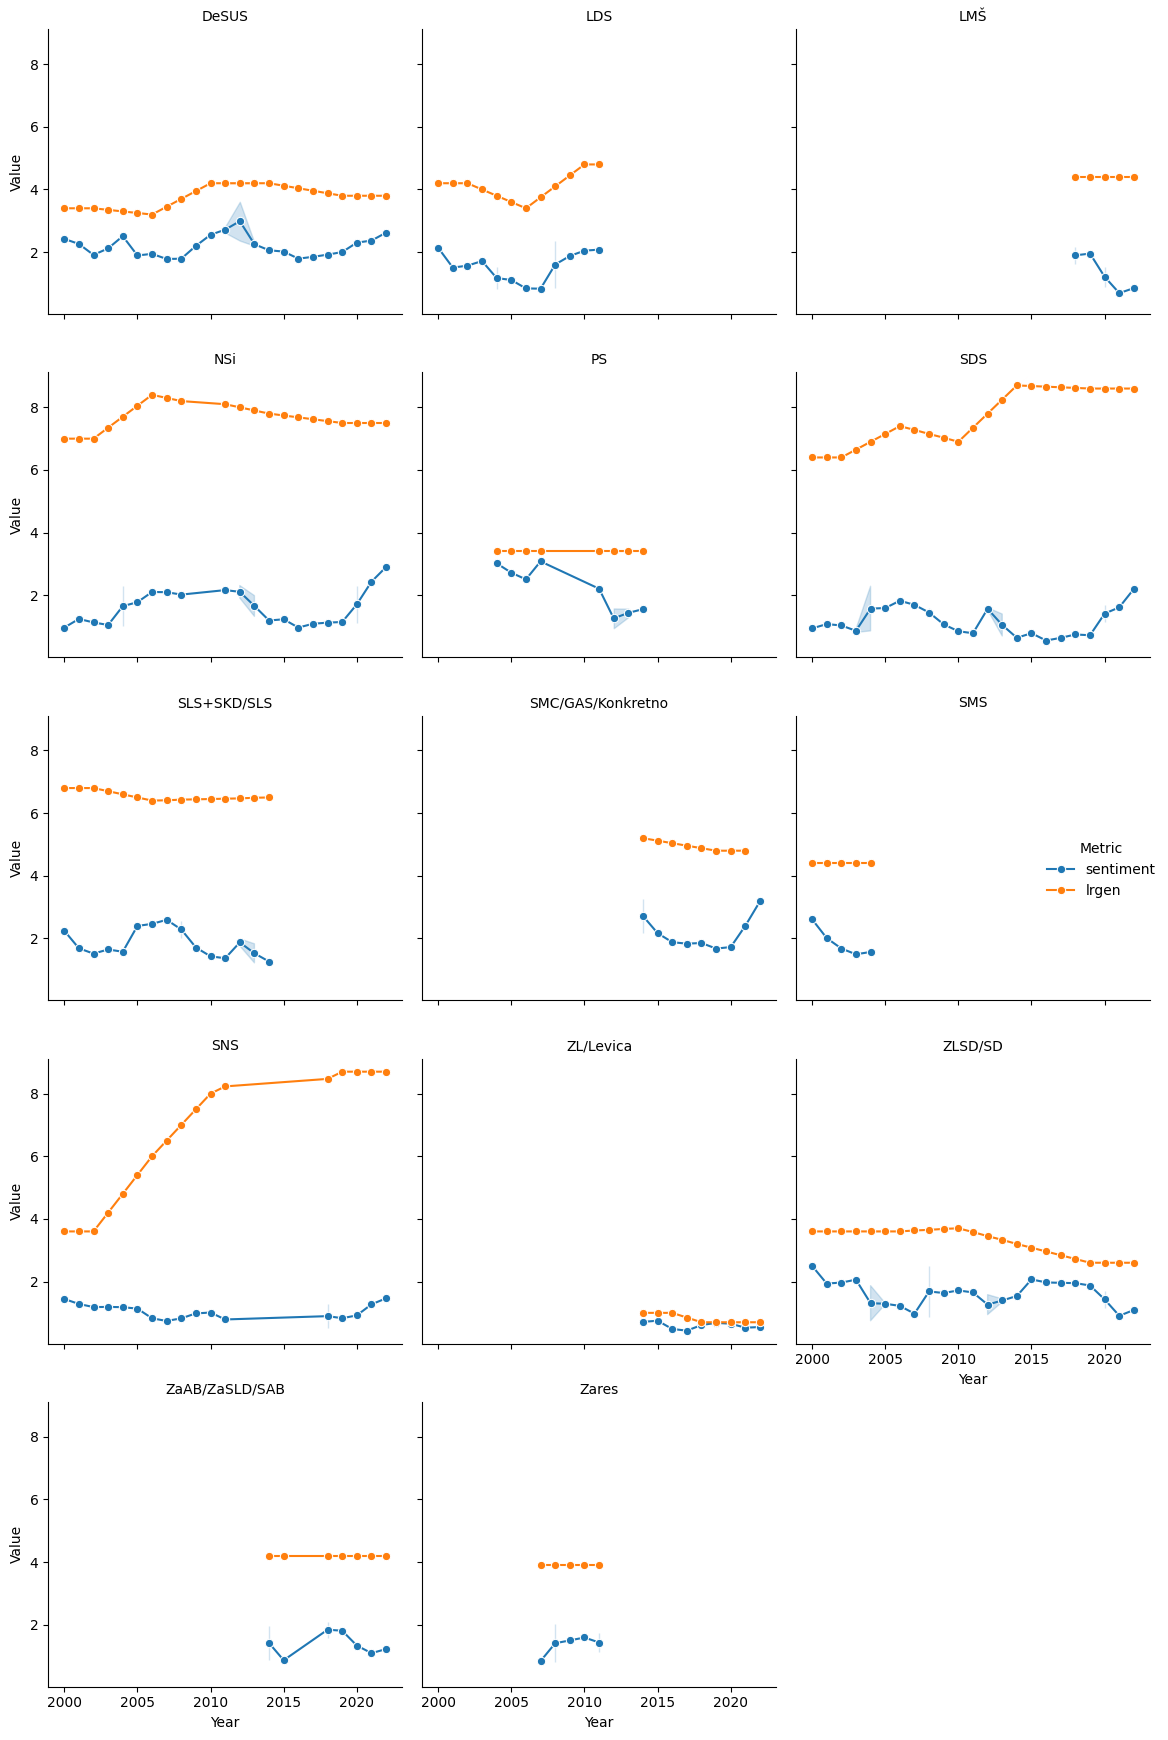

In [19]:
g = sns.FacetGrid(sent_lrgen, col="Parties", col_wrap=3, height=3.5, sharey=True, legend_out=True)
g.map_dataframe(sns.lineplot, x="Year", y="Value", hue="Metric",marker="o")

g.add_legend(title="Metric")
g.set_axis_labels("Year", "Value")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()

### Relationship between galtan and sentiment

In [20]:
df["galtan"] = pd.to_numeric(df["galtan"], errors="coerce")

sent_galtan = df.groupby(["Parties", "Party_status", "Year"]).agg(
    sentiment = ("Senti_n", "mean"),
    galtan = ("galtan", "mean"),
).reset_index()

sent_galtan = sent_galtan[~sent_galtan.isin(cols)]

In [21]:
sent_galtan = sent_galtan.melt(
    id_vars=["Parties", "Party_status", "Year"],
    value_vars=["sentiment", "galtan"],
    var_name="Metric",
    value_name="Value"
)

sent_galtan

,Parties,Party_status,Year,Metric,Value
0,NaN,NaN,2000,sentiment,2.710400
1,NaN,NaN,2001,sentiment,2.145257
2,NaN,NaN,2002,sentiment,2.049008
3,NaN,NaN,2003,sentiment,2.177101
4,NaN,NaN,2004,sentiment,2.143899
...,...,...,...,...,...
593,Zares,Coalition,2008,galtan,1.800000
594,Zares,Coalition,2009,galtan,1.800000
595,Zares,Coalition,2010,galtan,1.800000
596,Zares,Coalition,2011,galtan,1.800000


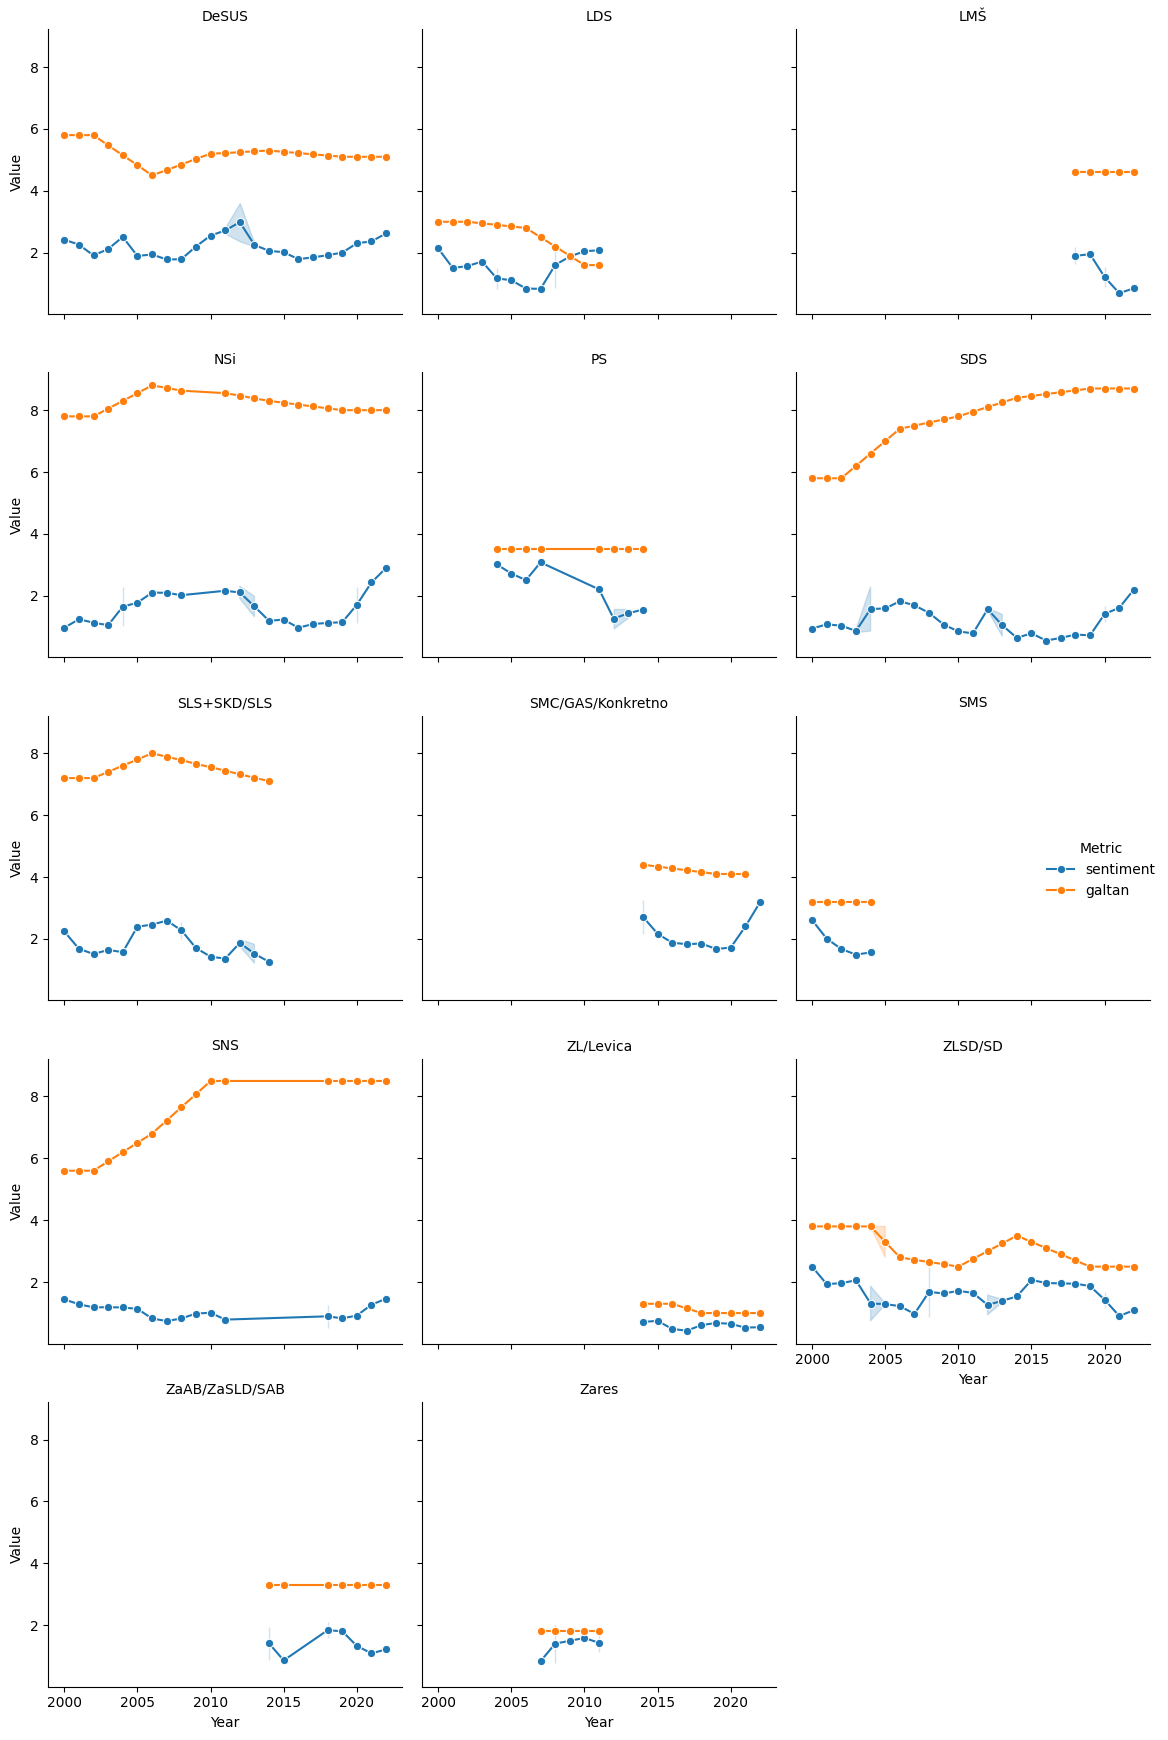

In [22]:
g = sns.FacetGrid(sent_galtan, col="Parties", col_wrap=3, height=3.5, sharey=True, legend_out=True)
g.map_dataframe(sns.lineplot, x="Year", y="Value", hue="Metric",marker="o")

g.add_legend(title="Metric")
g.set_axis_labels("Year", "Value")
g.set_titles("{col_name}")
plt.tight_layout()
plt.show()